# Patient Experience Analytics

In [ ]:
# this script analyzes the demo_patient_experience_data_NHC.csv dataset
# this is a demo survey dataset storing patient-experience-related information from an hypothetical laboratory
# the dataset has 20'000 observations and 9 fields

In [1]:
# before importing any library, run the statements below in the terminal
# when installing any package, make sure to be in the proper environment!
# conda install anaconda::pandas
# conda install conda-forge::matplotlib
# conda install conda-forge::plotly
# conda install conda-forge::nbformat
# conda install conda-forge::textblob

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from textblob import TextBlob

In [ ]:
# assign the path to the input file folder to a variable for reproducibility (and privacy)
input_folder_path = "path/to/input/file/folder/"

## 01: Laboratory Patient Experience

In [3]:
# read a CSV file into a data frame
df_lab = pd.read_csv(input_folder_path+"demo_patient_experience_data_NHC.csv")
df_lab

,Unnamed: 0,Entry Code,Feedback Date,Patient Age,Staff Rating,Speed Rating,Wait Time (minutes),Test Type,Review
0,0,1,2022-10-22,61,5,3,29,Urine Test,I couldn't have asked for better service from ...
1,1,2,2022-01-12,26,3,4,171,Biopsy,I'm indifferent about the service provided by ...
2,2,3,2022-04-06,53,3,5,176,Urine Test,My experience with the staff was neither good ...
3,3,4,2022-12-11,40,4,5,94,CT Scan,"I might consider returning for future tests, b..."
4,4,5,2022-10-31,96,2,1,165,Biopsy,"The service was poor, there are serious improv..."
...,...,...,...,...,...,...,...,...,...
19995,19995,19996,2022-09-01,34,3,2,128,CT Scan,"It was okay, the staff's performance was nothi..."
19996,19996,19997,2022-05-26,80,2,4,84,Blood Test,"I was quite disappointed, and there is a lot o..."
19997,19997,19998,2022-11-01,60,2,1,76,Ultrasound,"I was quite disappointed, and there is a lot o..."
19998,19998,19999,2022-10-09,62,1,5,16,Biopsy,There are no redeeming qualities about the ser...


In [4]:
# get rid of the 'Unnamed: 0' column
df_lab = df_lab.drop("Unnamed: 0", axis=1)
df_lab

,Entry Code,Feedback Date,Patient Age,Staff Rating,Speed Rating,Wait Time (minutes),Test Type,Review
0,1,2022-10-22,61,5,3,29,Urine Test,I couldn't have asked for better service from ...
1,2,2022-01-12,26,3,4,171,Biopsy,I'm indifferent about the service provided by ...
2,3,2022-04-06,53,3,5,176,Urine Test,My experience with the staff was neither good ...
3,4,2022-12-11,40,4,5,94,CT Scan,"I might consider returning for future tests, b..."
4,5,2022-10-31,96,2,1,165,Biopsy,"The service was poor, there are serious improv..."
...,...,...,...,...,...,...,...,...
19995,19996,2022-09-01,34,3,2,128,CT Scan,"It was okay, the staff's performance was nothi..."
19996,19997,2022-05-26,80,2,4,84,Blood Test,"I was quite disappointed, and there is a lot o..."
19997,19998,2022-11-01,60,2,1,76,Ultrasound,"I was quite disappointed, and there is a lot o..."
19998,19999,2022-10-09,62,1,5,16,Biopsy,There are no redeeming qualities about the ser...


In [5]:
# get a concise summary of the data frame
df_lab.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Entry Code           20000 non-null  int64
 1   Feedback Date        20000 non-null  str  
 2   Patient Age          20000 non-null  int64
 3   Staff Rating         20000 non-null  int64
 4   Speed Rating         20000 non-null  int64
 5   Wait Time (minutes)  20000 non-null  int64
 6   Test Type            20000 non-null  str  
 7   Review               20000 non-null  str  
dtypes: int64(5), str(3)
memory usage: 1.2 MB


In [6]:
# visualize the distribution of available 'Test Type' as a bar chart
px.bar(df_lab, x="Test Type", title="Distribution of Test Types", color="Test Type")

In [7]:
# visualize 'Staff Rating' against 'Speed Rating' as a box plot
fig = px.box(df_lab, x="Staff Rating", y="Speed Rating", title="Staff vs. Speed Ratings")
fig.show()

In [ ]:
# this is an hypothetical data set whose data comes from a uniform distribution...
# ... hence the median is obviously equal to 3, the first interquartile range to 2...
# ... the third interquartile to 4, the minimum to 1, and the maximum to 5

In [8]:
# visualize 'Wait Time (minutes)' as a violin plot
px.violin(df_lab, x="Wait Time (minutes)", title="Distribution of Wait Times", box=True)

In [ ]:
# the mean wait time is 93 minutes, the lowest is 5 minutes, the highest is 194 minutes

## 02: Sentiment Analysis of Patient Experience Reviews

In [ ]:
# TextBlob is a Python library that allows us to analyze...
# ... whether text reviews in 'Review' are positive, negative, or neutral

In [9]:
# read a CSV file into a data frame
df_experience = pd.read_csv(input_folder_path+"demo_patient_experience_data_NHC.csv")
df_experience

,Unnamed: 0,Entry Code,Feedback Date,Patient Age,Staff Rating,Speed Rating,Wait Time (minutes),Test Type,Review
0,0,1,2022-10-22,61,5,3,29,Urine Test,I couldn't have asked for better service from ...
1,1,2,2022-01-12,26,3,4,171,Biopsy,I'm indifferent about the service provided by ...
2,2,3,2022-04-06,53,3,5,176,Urine Test,My experience with the staff was neither good ...
3,3,4,2022-12-11,40,4,5,94,CT Scan,"I might consider returning for future tests, b..."
4,4,5,2022-10-31,96,2,1,165,Biopsy,"The service was poor, there are serious improv..."
...,...,...,...,...,...,...,...,...,...
19995,19995,19996,2022-09-01,34,3,2,128,CT Scan,"It was okay, the staff's performance was nothi..."
19996,19996,19997,2022-05-26,80,2,4,84,Blood Test,"I was quite disappointed, and there is a lot o..."
19997,19997,19998,2022-11-01,60,2,1,76,Ultrasound,"I was quite disappointed, and there is a lot o..."
19998,19998,19999,2022-10-09,62,1,5,16,Biopsy,There are no redeeming qualities about the ser...


In [10]:
# inspect the first review
df_experience["Review"][0]

"I couldn't have asked for better service from the staff, it was top-notch.. I had a fantastic experience, everything went smoothly and quickly.. The staff's expertise and dedication made my visit truly exceptional.. The staff was outstanding, I couldn't be happier with their service.. The staff was outstanding, I couldn't be happier with their service.. I couldn't have asked for better service from the staff, it was top-notch."

In [11]:
# apply the TextBlob() method to this review (i.e., make it a TextBlob object)
TextBlob(df_experience["Review"][0])

TextBlob("I couldn't have asked for better service from the staff, it was top-notch.. I had a fantastic experience, everything went smoothly and quickly.. The staff's expertise and dedication made my visit truly exceptional.. The staff was outstanding, I couldn't be happier with their service.. The staff was outstanding, I couldn't be happier with their service.. I couldn't have asked for better service from the staff, it was top-notch.")

In [12]:
# apply the 'sentiment' method to the TextBlob object
TextBlob(df_experience["Review"][0]).sentiment

Sentiment(polarity=0.58, subjectivity=0.765)

In [ ]:
# it has a polarity of 0.58, and a subjectivity of 0.765
# polarity relates to the emotional tone of a message, ranging from -1 to 1
# subjectivity ranges from 0 (if something is factual) to 1 (if something is opinionated)

In [13]:
# create a column named 'Polarity' that stores polarity values for each entry
# the 'lambda' function is a placeholder that picks a value x...
# ... and applies (in this case) TextBlob to it
df_experience["Polarity"] = df_experience["Review"].apply(lambda x : TextBlob(x).polarity)
df_experience

,Unnamed: 0,Entry Code,Feedback Date,Patient Age,Staff Rating,Speed Rating,Wait Time (minutes),Test Type,Review,Polarity
0,0,1,2022-10-22,61,5,3,29,Urine Test,I couldn't have asked for better service from ...,0.580000
1,1,2,2022-01-12,26,3,4,171,Biopsy,I'm indifferent about the service provided by ...,0.262121
2,2,3,2022-04-06,53,3,5,176,Urine Test,My experience with the staff was neither good ...,0.031506
3,3,4,2022-12-11,40,4,5,94,CT Scan,"I might consider returning for future tests, b...",0.171875
4,4,5,2022-10-31,96,2,1,165,Biopsy,"The service was poor, there are serious improv...",-0.421429
...,...,...,...,...,...,...,...,...,...,...
19995,19995,19996,2022-09-01,34,3,2,128,CT Scan,"It was okay, the staff's performance was nothi...",0.173214
19996,19996,19997,2022-05-26,80,2,4,84,Blood Test,"I was quite disappointed, and there is a lot o...",-0.194444
19997,19997,19998,2022-11-01,60,2,1,76,Ultrasound,"I was quite disappointed, and there is a lot o...",0.125000
19998,19998,19999,2022-10-09,62,1,5,16,Biopsy,There are no redeeming qualities about the ser...,-0.434091


In [14]:
# create a column named 'Subjectivity' that stores subjectivity values for each entry
df_experience["Subjectivity"] = df_experience["Review"].apply(lambda x : TextBlob(x).subjectivity)
df_experience

,Unnamed: 0,Entry Code,Feedback Date,Patient Age,Staff Rating,Speed Rating,Wait Time (minutes),Test Type,Review,Polarity,Subjectivity
0,0,1,2022-10-22,61,5,3,29,Urine Test,I couldn't have asked for better service from ...,0.580000,0.765000
1,1,2,2022-01-12,26,3,4,171,Biopsy,I'm indifferent about the service provided by ...,0.262121,0.650000
2,2,3,2022-04-06,53,3,5,176,Urine Test,My experience with the staff was neither good ...,0.031506,0.548752
3,3,4,2022-12-11,40,4,5,94,CT Scan,"I might consider returning for future tests, b...",0.171875,0.446875
4,4,5,2022-10-31,96,2,1,165,Biopsy,"The service was poor, there are serious improv...",-0.421429,0.650000
...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,19996,2022-09-01,34,3,2,128,CT Scan,"It was okay, the staff's performance was nothi...",0.173214,0.638095
19996,19996,19997,2022-05-26,80,2,4,84,Blood Test,"I was quite disappointed, and there is a lot o...",-0.194444,0.483333
19997,19997,19998,2022-11-01,60,2,1,76,Ultrasound,"I was quite disappointed, and there is a lot o...",0.125000,0.515000
19998,19998,19999,2022-10-09,62,1,5,16,Biopsy,There are no redeeming qualities about the ser...,-0.434091,0.740909


In [15]:
# create a column named 'Sentiment' that stores sentiment values for each entry...
# ... based on 'Polarity' and 'Subjectivity' values
df_experience["Sentiment"] = df_experience["Polarity"].apply(lambda x : "Positive" if x > 0 else "Neutral" if x == 0 else "Negative")
df_experience

,Unnamed: 0,Entry Code,Feedback Date,Patient Age,Staff Rating,Speed Rating,Wait Time (minutes),Test Type,Review,Polarity,Subjectivity,Sentiment
0,0,1,2022-10-22,61,5,3,29,Urine Test,I couldn't have asked for better service from ...,0.580000,0.765000,Positive
1,1,2,2022-01-12,26,3,4,171,Biopsy,I'm indifferent about the service provided by ...,0.262121,0.650000,Positive
2,2,3,2022-04-06,53,3,5,176,Urine Test,My experience with the staff was neither good ...,0.031506,0.548752,Positive
3,3,4,2022-12-11,40,4,5,94,CT Scan,"I might consider returning for future tests, b...",0.171875,0.446875,Positive
4,4,5,2022-10-31,96,2,1,165,Biopsy,"The service was poor, there are serious improv...",-0.421429,0.650000,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,19996,2022-09-01,34,3,2,128,CT Scan,"It was okay, the staff's performance was nothi...",0.173214,0.638095,Positive
19996,19996,19997,2022-05-26,80,2,4,84,Blood Test,"I was quite disappointed, and there is a lot o...",-0.194444,0.483333,Negative
19997,19997,19998,2022-11-01,60,2,1,76,Ultrasound,"I was quite disappointed, and there is a lot o...",0.125000,0.515000,Positive
19998,19998,19999,2022-10-09,62,1,5,16,Biopsy,There are no redeeming qualities about the ser...,-0.434091,0.740909,Negative


In [16]:
# count unique 'Sentiment' values
sentiment_counts = df_experience["Sentiment"].value_counts()
sentiment_counts

Sentiment
Positive    12740
Negative     7242
Neutral        18
Name: count, dtype: int64

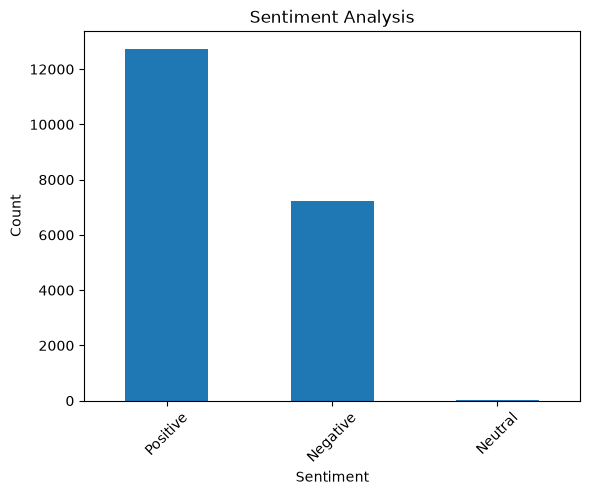

In [17]:
# plot unique 'Sentiment' values as a bar chart
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()